# 다중 회귀와 예측 결과 분석

> 여러 입력 변수를 함께 사용해 더 정확한 회귀 모델을 만들고, 예측 결과를 깊이 있게 분석

| 구분 | 입력 변수 개수 | 예측식 |
| - | - | - |
| 단순 회귀 | 1개 | `점수 = a * 공부시간 + b` |
| 다중 회귀 | 여러 개 | `점수 = a(1) * 공부시간 + a(2) * 출석률 + a(3) * 과제 점수 + b` |

-> 각 변수마다 자신의 계수(coef, 가중치)를 갖고, 모든 항을 더한 뒤 마지막 절편(interp_)을 더해 예측값을 만든다.

## 라이브러리 불러오기

In [ ]:
%pip install pandas scikit-learn
%pip install matplotlib

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [19]:
student_df = pd.DataFrame ({
    # 하루 평균 공부 시간
    "study_hours": [1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 11],
    # 출석률
    "attendance": [50, 50, 55, 60, 60, 55, 65, 70, 75, 65,  75, 70, 80, 70, 80, 85, 90, 90, 95, 100],
    # 과제 점수
    "assignment": [40, 45, 50, 55, 60, 60, 55, 65, 70, 75, 65, 75, 70, 80, 70, 85, 90, 90, 95, 100],
    # 최종 시험 점수, 모델이 예측해야 할 값
    "score": [45, 50, 52, 55, 58, 60, 64, 67, 71, 76, 79, 83, 84, 87, 88, 90, 94, 95, 97, 99]
})

student_df.head()

,study_hours,attendance,assignment,score
0,1,50,40,45
1,2,50,45,50
2,2,55,50,52
3,3,60,55,55
4,3,60,60,58


## 데이터 살펴보기

In [20]:
student_df.describe()

,study_hours,attendance,assignment,score
count,20.000000,20.000000,20.000000,20.000000
mean,6.000000,72.000000,69.750000,74.700000
std,2.991215,14.903196,16.739097,17.302571
min,1.000000,50.000000,40.000000,45.000000
25%,3.750000,60.000000,58.750000,59.500000
50%,6.000000,70.000000,70.000000,77.500000
75%,8.250000,81.250000,81.250000,88.500000
max,11.000000,100.000000,100.000000,99.000000


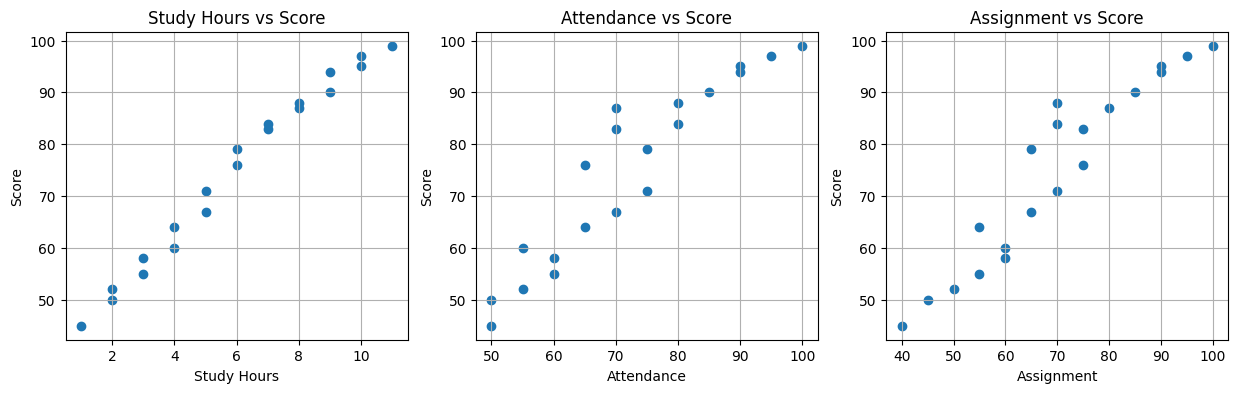

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(student_df['study_hours'], student_df['score'])
axes[0].set_title('Study Hours vs Score')
axes[0].set_xlabel('Study Hours')
axes[0].set_ylabel('Score')
axes[0].grid(True)

axes[1].scatter(student_df['attendance'], student_df['score'])
axes[1].set_title('Attendance vs Score')
axes[1].set_xlabel('Attendance')
axes[1].set_ylabel('Score')
axes[1].grid(True)

axes[2].scatter(student_df['assignment'], student_df['score'])
axes[2].set_title('Assignment vs Score')
axes[2].set_xlabel('Assignment')
axes[2].set_ylabel('Score')
axes[2].grid(True)

## 단순 회귀 모델 만들기 (비교용 베이스라인)

다중 회귀와 성능을 비교할 때 기준점(baseline)으로 사용

In [22]:
X = student_df[['study_hours']]
y = student_df['score']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20, 1)
y shape: (20,)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print('훈련 데이터 개수: ', len(X_train))
print('테스트 데이터 개수: ', len(X_test))

# 모델 학습
model = LinearRegression()
model.fit(X_train, y_train)

print('모델 학습 완료')
print(f'기울기: {model.coef_[0]:.3f}')
print(f'절편: {model.intercept_:.3f}')

# 예측 점수 = 기울기 * study_hours + 절편
pred = model.predict(X_test)
print('예측 완료')

훈련 데이터 개수:  14
테스트 데이터 개수:  6
모델 학습 완료
기울기: 5.691
절편: 41.181
예측 완료


## 다중 회귀 모델 학습하기

In [27]:
X_multi = student_df[['study_hours', 'attendance', 'assignment']]
y_multi = student_df['score']

print('X_multi 모양: ', X_multi.shape)
print('y_multi 모양: ', y_multi.shape)

# 훈련 / 테스트 데이터 분리
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, test_size=0.3, random_state=42)

# 모델 학습
model_multi = LinearRegression()
model_multi.fit(X_train_multi, y_train_multi)

print('다중 회귀 모델 학습 완료')

X_multi 모양:  (20, 3)
y_multi 모양:  (20,)
다중 회귀 모델 학습 완료


## 다중 회귀 모델의 개수 해석하기

예측 점수 = a(1) * study_hours + a(2) + attendance + a(3) * assignment + b(절편)

`a(1)`, `a(2)`, `a(3)`은 각 변수의 계수(coef_), `b`는 절편(intercept_)

각 계수의 의미: 다른 변수가 모두 그대로일 때, 해당 변수가 1만큼 증가하면서 예측 점수가 계수만큼 변화

단, 변수마다 단위가 다르므로 **계수의 절댓값만 보고 변수의 중요도를 비교하면 안 됨**

In [28]:
coef_df = pd.DataFrame({
    'feature': X_multi.columns,
    'coefficient': model_multi.coef_,
})

print(f'절편: {model_multi.intercept_:.3f}')
coef_df

절편: 54.452


,feature,coefficient
0,study_hours,7.371838
1,attendance,-0.108589
2,assignment,-0.221926


- `study_hours`의 계수가 양수이면, 공부 시간이 1시간 늘어날 때 예측 점수가 그만큼 증가
- `attendance`의 계수가 양수이면, 출셕률 1%p 늘어날 때 예측 점수가 그만큼 증가
- `assignment`의 계수가 양수이면, 과제 점수가 1점 늘어날 때 예측 점수가 그만큼 증가

만약 어떤 계수가 **음수**라면, 그 변수가 커질수록 예측값은 작아짐

## 문제

위에서 얻은 계수와 절편을 이용해, 다음 학생의 예측 점수를 계산한다.

- `study_hours` = 6
- `attendance` = 80
- `assignment` = 75

예측 점수 = study_hours 계수 * 6 <br>
        + attendance 계수 * 80 <br>
        + assignment 계수 * 75 <br>
        + 절편
        

In [33]:
new_student = pd.DataFrame ({
    "study_hours": [6],
    "attendance": [80],
    "assignment": [75]
})
predicted_score = model_multi.predict(new_student)[0]

print(f'예상 점수: {predicted_score:.1f}점')

예상 점수: 73.4점


## 단순 회귀 VS 다중 회귀 성능 비교

- `MAE`: 평균적으로 몇 점 차이로 틀리는가 (작을수록 좋음)
- `R²`: 모델이 점수의 변화를 얼마나 잘 설명하는가 (1에 가까울수록 좋음)

In [29]:
# 다중 회귀 예측
multi_pred = model_multi.predict(X_test_multi)

# 단순 회귀 평가
simple_mae = mean_absolute_error(y_test, pred)
simple_r2 = r2_score(y_test, pred)

# 다중 회귀 평가
multi_mae = mean_absolute_error(y_test_multi, multi_pred)
multi_r2 = r2_score(y_test_multi, multi_pred)

compare_df = pd.DataFrame({
    'model': ['Study_hours only', 'study_hours + attendance + assignment'],
    'MAE': [simple_mae, multi_mae],
    'R²': [simple_r2, multi_r2]
})

compare_df

,model,MAE,R²
0,Study_hours only,2.537840,0.979996
1,study_hours + attendance + assignment,3.407661,0.966013


결과 해석

- 다중 회귀의 `MAE`가 단순 회귀보다 훨씬 작다 -> 평균 오차가 더 작다는 뜻
- 다중 회귀의 `R²`가 단순 회귀보다 1에 더 가깝다 -> 데이터의 패턴을 더 잘 설명한다는 뜻

이는 **출석률**과 **과제 점수**가 단순히 "공부 시간으로는 설명되지 않는 추가 정보"를 모델에 제공했기 때문

> **주의** - 변수를 무조건 많이 넣는다고 항상 좋아지지는 않음 / 의미없는 변수가 들어오면 오히려 Noise가 늘어나 성능이 떨어지거나(과적합), 결과 해석이 어려워질 수 있음. <br> 머신러닝 과목에서 `변수 선택(feture selection)`으로 깊이 다룸.